# Set-up

In [1]:
import os
from collections import defaultdict
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tqdm import tqdm
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms


In [2]:
import wandb

try:
    from kaggle_secrets import UserSecretsClient
    user_secrets = UserSecretsClient()
    api_key = user_secrets.get_secret("wandb_api")
    wandb.login(key=api_key)
    anony = None
except:
    anony = "must"
    print('If you want to use your W&B account, go to Add-ons -> Secrets and provide your W&B access token. Use the Label name as wandb_api. \nGet your W&B access token from here: https://wandb.ai/authorize')

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: iq000012 (infinitasfish). Use `wandb login --relogin` to force relogin
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


# Data prep.

In [5]:
ds_path = '../input/anomaly/dataset'

In [6]:
for root, dirs, paths in os.walk(ds_path):
  print(root, dirs, len(paths))

../input/anomaly/dataset ['proliv', 'test', 'train'] 0
../input/anomaly/dataset/proliv [] 154
../input/anomaly/dataset/test ['imgs'] 1
../input/anomaly/dataset/test/imgs [] 3794
../input/anomaly/dataset/train [] 10000


In [7]:
class anomaly_dataset(Dataset):
  def __init__(self, ds_path, split, annotations_file=None, transform=None):
    self.ds_path = ds_path
    self.split = split.lower()

    if (self.split == 'test' and annotations_file is not None):
      test_images = os.path.join(self.ds_path, 'test', 'imgs')
      test_labels = os.path.join(self.ds_path, 'test', annotations_file)

      self.images_paths = sorted(os.listdir(test_images))
      self.labels_list = []
      with open(test_labels, 'r') as f:
        lines = sorted([line for line in f], key=lambda l: l.split()[0])
        self.labels_list = [int(line.split()[1]) for line in lines]
    else:
      split_path = os.path.join(self.ds_path, self.split)
      self.images_paths = sorted(os.listdir(split_path))

    self.transform = transform

  def __len__(self):
    return len(self.images_paths)

  def __getitem__(self, index):
    if self.split == 'test':
      label = self.labels_list[index]
      image_path = os.path.join(self.ds_path, self.split, 'imgs', self.images_paths[index])
      image = cv2.imread(image_path)
      image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
      image_t = self.transform(image)
      image_t = transforms.functional.adjust_contrast(image_t, contrast_factor=1.3)
      return image_t, label
    else:
      image_path = os.path.join(ds_path, self.split, self.images_paths[index])
      image = cv2.imread(image_path)
      image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
      image_t = self.transform(image)
      image_t = transforms.functional.adjust_contrast(image_t, contrast_factor=1.3)
      return image_t


In [8]:
norm_tform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = anomaly_dataset(ds_path, 'train', transform=norm_tform)
proliv_ds = anomaly_dataset(ds_path, 'proliv', transform=norm_tform)
test_ds = anomaly_dataset(ds_path, 'test', 'test_annotation.txt', transform=norm_tform)
print(len(train_ds), len(proliv_ds), len(test_ds))


10000 154 3794


torch.Size([3, 64, 64])


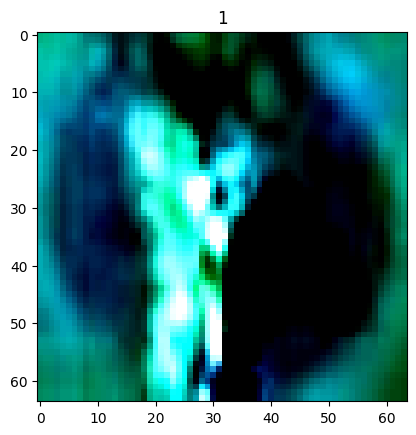

In [9]:
for i in range(len(test_ds)):
  image, label = test_ds[i]
  if i == 1000: break
  if label == 1: break

plt.title(str(label))
plt.imshow(image.squeeze().permute(1, 2, 0).cpu().numpy())
print(image.shape)

# Baselines

In [10]:
## Linear baseline
class AE(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Linear(1500, 784),
            nn.ReLU(),
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU()
        )

        self.dec = nn.Sequential(
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.ReLU(),
            nn.Linear(784, 1500),
            nn.ReLU()
        )

    def forward(self, x):
        x = torch.flatten(x, start_dim=1)
        encode = self.enc(x)
        decode = self.dec(encode)
        return decode

In [51]:
## Convolution baseline

class AE5(nn.Module):
    def __init__(self, scale_factor=1):
        super(AE5, self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, int(32*scale_factor), kernel_size=3, padding=1),  
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), 

            nn.Conv2d(int(32*scale_factor), int(64*scale_factor), kernel_size=3, padding=1), 
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(int(64*scale_factor), int(128*scale_factor), kernel_size=3, padding=1),
            nn.ReLU(),
            #nn.MaxPool2d(kernel_size=2, stride=2),
        )
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(int(128*scale_factor), int(64*scale_factor), kernel_size=2, stride=2),  
            nn.ReLU(),
            nn.Conv2d(int(64*scale_factor), int(64*scale_factor), kernel_size=3, padding=1),
            nn.ReLU(),
            
            nn.ConvTranspose2d(int(64*scale_factor), int(32*scale_factor), kernel_size=2, stride=2),
            nn.ReLU(),
            nn.Conv2d(int(32*scale_factor), int(32*scale_factor), kernel_size=3, padding=1),
            nn.ReLU(),
            
            nn.Conv2d(int(32*scale_factor), 3, kernel_size=3, padding=1),  
            nn.Sigmoid()  
        )
        
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

# Train loop

In [52]:
t = torch.randn((128, 3, 64, 64))
model = AE5(scale_factor=1.25)
r = model(t)
print(r.shape)
model

torch.Size([128, 3, 64, 64])


AE5(
  (encoder): Sequential(
    (0): Conv2d(3, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(40, 80, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(80, 160, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(160, 80, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU()
    (2): Conv2d(80, 80, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(80, 40, kernel_size=(2, 2), stride=(2, 2))
    (5): ReLU()
    (6): Conv2d(40, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): Conv2d(40, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): Sigmoid()
  )
)

In [53]:
batch_size = 256
lr = 6e-3
w_d = 1e-6
epochs = 25

In [54]:
tfrom_aug = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(0.3),
    transforms.RandomVerticalFlip(0.3),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = anomaly_dataset(ds_path, 'train', transform=tfrom_aug)
proliv_ds = anomaly_dataset(ds_path, 'proliv', transform=norm_tform)

train_dl = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
)

proliv_dl = DataLoader(
    proliv_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
)

In [55]:
metrics = defaultdict(list)
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

model.to(device)
criterion = nn.MSELoss(reduction='mean')
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=w_d)

In [56]:
run = wandb.init(
    project="_ae5_train_",
    config={
        "learning_rate": lr,
        "epochs": epochs,
    },
)

In [57]:

start = time.time()
for epoch in tqdm(range(epochs)):
  ep_start = time.time()
  running_loss = 0.0
  model.train()
  for i, data in enumerate(train_dl):
    pred = model(data.to(device))
    loss = criterion(data.to(device), pred)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    running_loss += loss.item()

  model.eval()
  # по идее должно падать медленнее
  running_eval_loss = 0.0
  for i, data in enumerate(proliv_dl):
    pred = model(data.to(device))
    loss = criterion(data.to(device), pred)
    running_eval_loss += loss.item()

  epoch_loss = running_loss/len(train_dl)
  epoch_val_loss = running_eval_loss/len(proliv_dl)
  wandb.log({'epoch': epoch,
             'train_loss': epoch_loss,
             'val_loss': epoch_val_loss})

  metrics['train_loss'].append(epoch_loss)
  metrics['val_loss'].append(epoch_val_loss)
  ep_end = time.time()
  print('\n-----------------------------------------------')
  print(f'epoch: {epoch}\ttrain_loss: {epoch_loss:.5f}\tval_loss: {epoch_val_loss}')
  print(f'epoch completed in {(ep_end-ep_start)/60:.2f} mins')

end = time.time()
print('\n-----------------------------------------------')
print(f'training completed in {(end-start)/60:.2f} mins')

  4%|▍         | 1/25 [00:17<07:11, 17.97s/it]


-----------------------------------------------
epoch: 0	train_loss: 0.03449	val_loss: 0.04434505105018616
epoch completed in 0.30 mins


  8%|▊         | 2/25 [00:30<05:42, 14.91s/it]


-----------------------------------------------
epoch: 1	train_loss: 0.00706	val_loss: 0.021139981225132942
epoch completed in 0.21 mins


 12%|█▏        | 3/25 [00:43<05:03, 13.79s/it]

...


-----------------------------------------------
epoch: 22	train_loss: 0.00065	val_loss: 0.012719751335680485
epoch completed in 0.18 mins


 96%|█████████▌| 24/25 [04:55<00:10, 10.84s/it]


-----------------------------------------------
epoch: 23	train_loss: 0.00065	val_loss: 0.01260609645396471
epoch completed in 0.18 mins


100%|██████████| 25/25 [05:06<00:00, 12.27s/it]


-----------------------------------------------
epoch: 24	train_loss: 0.00097	val_loss: 0.012965545058250427
epoch completed in 0.19 mins

-----------------------------------------------
training completed in 5.11 mins


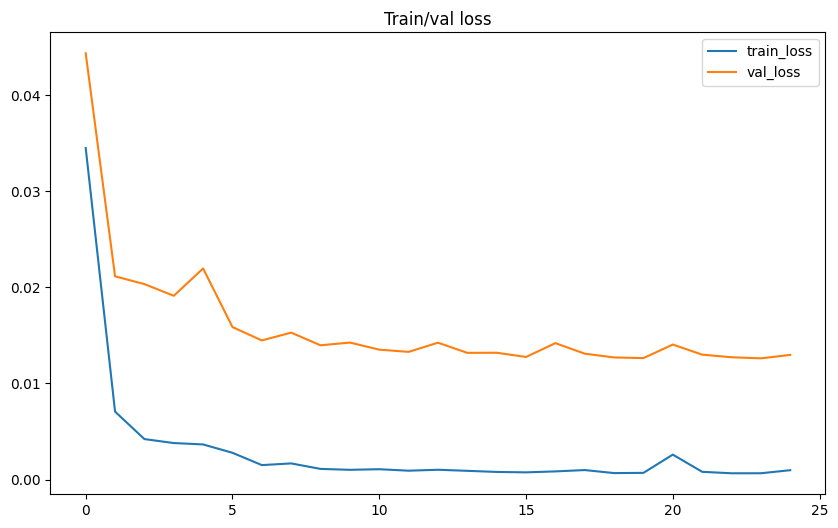

In [58]:
_, ax = plt.subplots(1,1,figsize=(10,6))
ax.set_title('Train/val loss')
ax.plot(metrics['train_loss'], label='train_loss')
ax.plot(metrics['val_loss'], label='val_loss')
ax.legend()

In [59]:
checkpoint = {'model': AE5(scale_factor=1.25),
              'state_dict': model.state_dict(),
              'optimizer' : optimizer.state_dict()}

torch.save(checkpoint, 'ae5_checkpoint.pth')

# Threshold

In [60]:
train_dl = DataLoader(
    train_ds,
    batch_size=1,
    shuffle=True,
    num_workers=2,
)

proliv_dl = DataLoader(
    proliv_ds,
    batch_size=1,
    shuffle=True,
    num_workers=2,
)

loss_dist_pos = []
loss_dist_neg = []

model.eval()

# what if using 'sum' reduction to distict anomalies more easily..
criterion = nn.MSELoss(reduction='sum')

for i, data in tqdm(enumerate(train_dl)):
    pred = model(data.to(device))
    loss = criterion(data.to(device), pred)
    loss_dist_neg.append(loss.detach().cpu().numpy())

for i, data in tqdm(enumerate(proliv_dl)):
    pred = model(data.to(device))
    loss = criterion(data.to(device), pred)
    loss_dist_pos.append(loss.detach().cpu().numpy())

10000it [00:23, 424.99it/s]
154it [00:00, 366.38it/s]


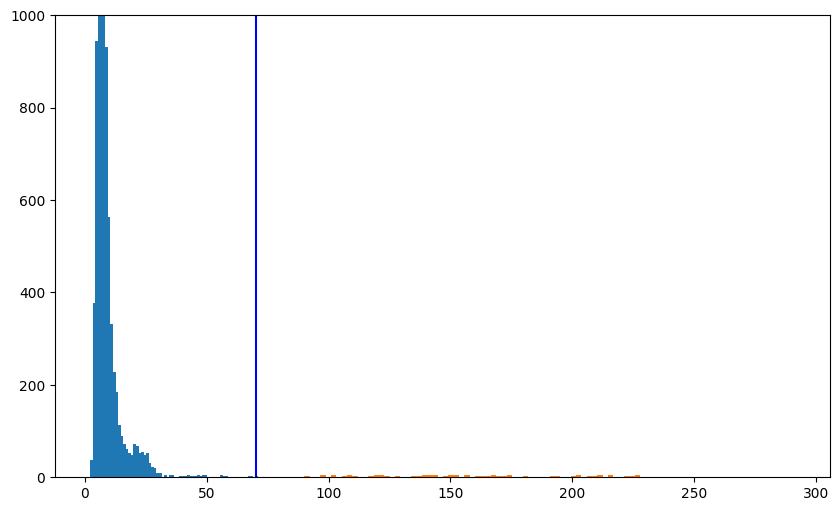

In [61]:
thr = 70
plt.figure(figsize=(10, 6))
plt.ylim(0, 1000)
plt.hist(loss_dist_neg, bins=100)
plt.hist(loss_dist_pos, bins=100)

plt.axvline(x=thr, color='b')
plt.show()

# Testing

torch.Size([128, 3, 64, 64]) torch.Size([128, 3, 64, 64])


<Figure size 1600x1200 with 0 Axes>

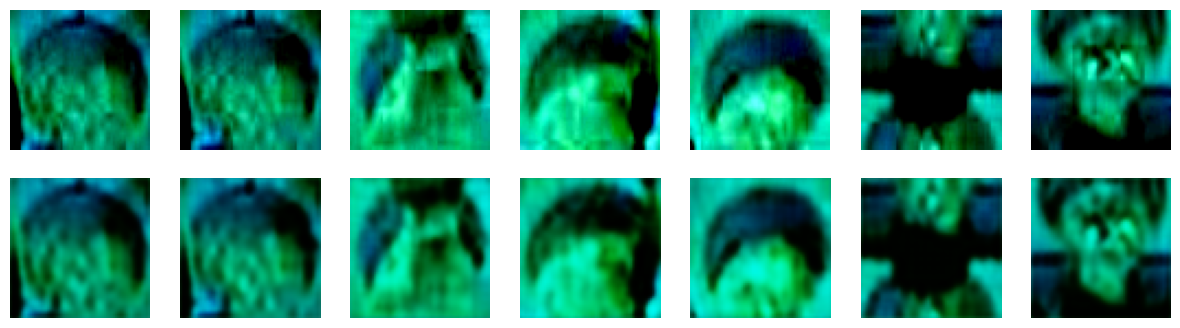

In [62]:
test_dl = DataLoader(
    test_ds,
    batch_size=128,
    shuffle=True,
    num_workers=2,
)

with torch.no_grad():
    for data, labels in test_dl:
        data = data.to(device)
        recon = model(data)
        break

print(data.shape, recon.shape)
plt.figure(dpi=250)
fig, ax = plt.subplots(2, 7, figsize=(15, 4))
for i in range(7):
    ax[0, i].set_xlabel(labels[i])
    ax[0, i].imshow(data[i].cpu().numpy().transpose((1, 2, 0)))
    ax[1, i].imshow(recon[i].cpu().numpy().transpose((1, 2, 0)))
    ax[0, i].axis('OFF')
    ax[1, i].axis('OFF')

In [63]:
def predict_label(model, image, thresh, criterion, device):
  pred = model(image.to(device))
  loss = criterion(image.to(device), pred)

  if loss > thresh: return 1
  else: return 0

In [64]:
test_dl = DataLoader(
    test_ds,
    batch_size=1,
    shuffle=True,
    num_workers=2,
)

low_thr = 0
high_thr= 200
step = 10
cur_thr = low_thr

thrs_all = []

best_thr= -1
best_f1 = -1

metrics = defaultdict(list)
TP, TN, FP, FN = 0, 0, 0, 0
TPR, TNR = 0, 0
model.eval()

while (cur_thr < high_thr):
  thrs_all.append(cur_thr)
  for i, (image, label) in enumerate(test_dl):
    pred_label = predict_label(model, image, cur_thr, criterion, device)

    if label == 0:
      if pred_label == 0: TN += 1
      elif pred_label == 1: FP += 1
    elif label == 1:
      if pred_label == 0: FN += 1
      elif pred_label == 1: TP += 1

  precision = TP / (TP + FP)
  recall = TP / (TP + FN)
  TPR = TP/(TP+FN)
  TNR = TN/(TN+FP)
  f1 = 2 * precision * recall / (precision + recall)

  if f1 > best_f1:
    best_thr = cur_thr
    best_f1 = f1

  metrics['precision'].append(precision)
  metrics['recall'].append(recall)
  metrics['tpr'].append(TPR)
  metrics['tnr'].append(TNR)
  metrics['f1'].append(f1)

  wandb.log({'threshold': thr,
             'precision': precision,
             'recall': recall,
             'tnr': TNR,
             'tpr': TPR,
             'f1': f1})

  print('--------------------------------------------------------------------------------------------------------------\n')
  print(f'threshold: {cur_thr:.6f}\tprecision: {precision:.4f}\trecall: {recall:.4f}\tf1 {f1:.4f}\tTPR: {TPR:.4f}\tTNR: {TNR:.4f}')

  cur_thr += step


--------------------------------------------------------------------------------------------------------------

threshold: 0.000000	precision: 0.0340	recall: 1.0000	f1 0.0658	TPR: 1.0000	TNR: 0.0000
--------------------------------------------------------------------------------------------------------------

threshold: 10.000000	precision: 0.0378	recall: 0.9225	f1 0.0725	TPR: 0.9225	TNR: 0.1726
--------------------------------------------------------------------------------------------------------------

threshold: 20.000000	precision: 0.0476	recall: 0.8708	f1 0.0902	TPR: 0.8708	TNR: 0.3863
--------------------------------------------------------------------------------------------------------------

threshold: 30.000000	precision: 0.0584	recall: 0.8430	f1 0.1092	TPR: 0.8430	TNR: 0.5212
--------------------------------------------------------------------------------------------------------------

threshold: 40.000000	precision: 0.0691	recall: 0.8248	f1 0.1276	TPR: 0.8248	TNR: 0.6092
-

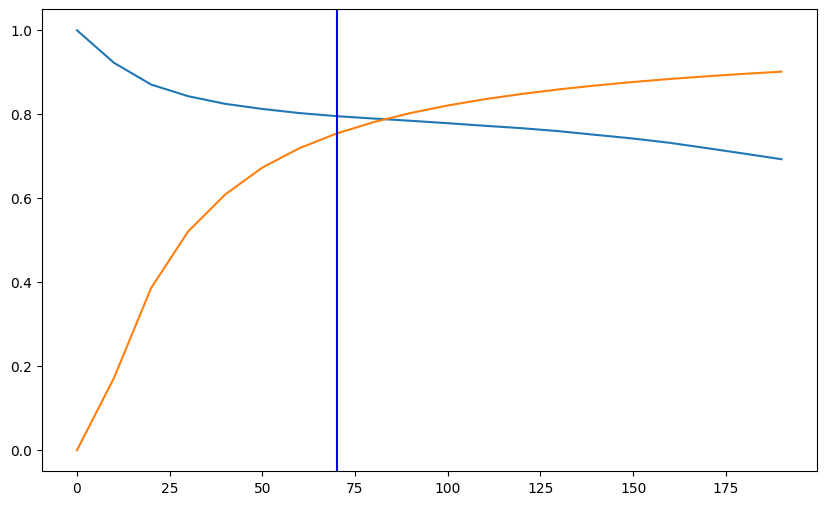

In [65]:
# проверяем насколько подобранный на основе нетестовых данных трешхолд близок к идеальному
thr = 70

plt.figure(figsize=(10, 6))

plt.plot(thrs_all, metrics['tpr'], label='TPR') 
plt.plot(thrs_all, metrics['tnr'], label='TNR')
plt.axvline(x=thr, color='b')